In [1]:
import torch
import pandas as pd

print("Torch:", torch.__version__)
print("Pandas:", pd.__version__)

Torch: 2.2.2+cu121
Pandas: 2.3.3


In [3]:
drug_protein = pd.read_csv("../data/interim/drug_protein_edges.csv")
protein_disease = pd.read_csv("../data/interim/protein_disease_edges.csv")
protein_protein = pd.read_csv("../data/interim/protein_protein_edges.csv")

print("Drug-Protein:", drug_protein.shape)
print("Protein-Disease:", protein_disease.shape)
print("Protein-Protein:", protein_protein.shape)

Drug-Protein: (26766, 3)
Protein-Disease: (38959, 2)
Protein-Protein: (472588, 2)


In [4]:
drug_protein.head()

,drug_id,drug_name,protein_id
0,DB00001,Lepirudin,P00734
1,DB00002,Cetuximab,P00533
2,DB00002,Cetuximab,O75015
3,DB00002,Cetuximab,P02745
4,DB00002,Cetuximab,P02746


In [5]:
protein_disease.head()

,protein,disease
0,P00734,Hereditary factor II deficiency disease
1,P00734,Thrombosis
2,P00734,Venous Thrombosis
3,P00734,Thrombophilia
4,P00734,Blood Coagulation Disorders


In [6]:
protein_protein.head()

,protein1,protein2
0,P84085,Q15027
1,P84085,P53621
2,P84085,X6RFI8
3,P84085,P35606
4,P84085,O14579


In [7]:
from collections import defaultdict

In [8]:
disease_to_proteins = defaultdict(set)

for _, row in protein_disease.iterrows():
    disease_to_proteins[row["disease"]].add(row["protein"])

print("Total diseases:", len(disease_to_proteins))

Total diseases: 7687


In [9]:
protein_to_drugs = defaultdict(set)

for _, row in drug_protein.iterrows():
    protein_to_drugs[row["protein_id"]].add(
        (row["drug_id"], row["drug_name"])
    )

print("Proteins targeted by drugs:", len(protein_to_drugs))

Proteins targeted by drugs: 5096


In [10]:
protein_network = defaultdict(set)

for _, row in protein_protein.iterrows():
    
    p1 = row["protein1"]
    p2 = row["protein2"]
    
    protein_network[p1].add(p2)
    protein_network[p2].add(p1)

print("Proteins in interaction network:", len(protein_network))

Proteins in interaction network: 16050


In [47]:
def recommend_drugs_advanced(disease_name, top_n=5):

    if disease_name not in disease_to_proteins:
        print("Disease not found in dataset")
        return None

    disease_proteins = disease_to_proteins[disease_name]

    candidate_proteins = set()
    candidate_proteins.update(disease_proteins)

    # Add interacting proteins (limited)
    for protein in disease_proteins:

        if protein in protein_network:

            interactions = list(protein_network[protein])[:10]
            candidate_proteins.update(interactions)

    drug_scores = defaultdict(int)
    drug_names = {}

    # Drugs to ignore (network hub minerals)
    ignore_drugs = {
        "Zinc",
        "Zinc acetate",
        "Zinc sulfate, unspecified form",
        "Zinc chloride",
        "Copper"
    }

    for protein in candidate_proteins:

        if protein in protein_to_drugs:

            for drug_id, drug_name in protein_to_drugs[protein]:

                # Skip hub drugs
                if drug_name in ignore_drugs:
                    continue

                drug_scores[drug_id] += 1
                drug_names[drug_id] = drug_name

    scored_drugs = []

    for drug_id, count in drug_scores.items():

        scored_drugs.append((drug_id, drug_names[drug_id], count))

    scored_drugs = sorted(scored_drugs, key=lambda x: x[2], reverse=True)

    return scored_drugs[:top_n]

In [51]:
#INPUT DISEASE NAME
disease = "Hereditary factor II deficiency disease"

recommendations = recommend_drugs_advanced(disease)

recommendations

[('DB00055', 'Drotrecogin alfa', 3),
 ('DB11300', 'Thrombin', 2),
 ('DB13151', 'Anti-inhibitor coagulant complex', 2),
 ('DB19834', 'Razaxaban', 2),
 ('DB05777', 'Thrombomodulin Alfa', 2)]

In [52]:
results_df = pd.DataFrame(
    recommendations,
    columns=["Drug ID", "Drug Name", "Score"]
)

results_df

,Drug ID,Drug Name,Score
0,DB00055,Drotrecogin alfa,3
1,DB11300,Thrombin,2
2,DB13151,Anti-inhibitor coagulant complex,2
3,DB19834,Razaxaban,2
4,DB05777,Thrombomodulin Alfa,2


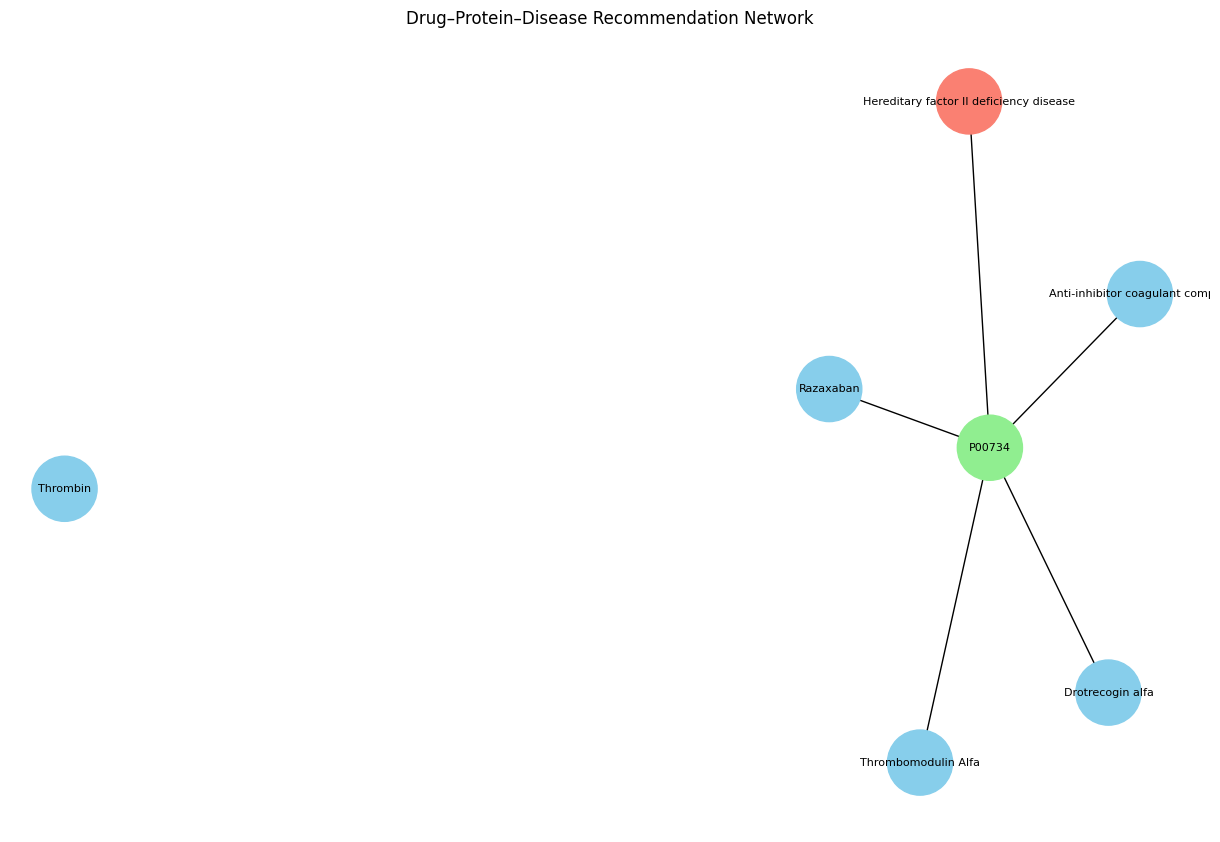

In [53]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph
G = nx.Graph()

# Add disease node
G.add_node(disease, node_type="disease")

disease_proteins = disease_to_proteins[disease]

for drug_id, drug_name, score in recommendations:

    # Add drug node
    G.add_node(drug_name, node_type="drug")

    for protein in disease_proteins:

        if protein in protein_to_drugs:

            for d_id, d_name in protein_to_drugs[protein]:

                if d_id == drug_id:

                    # Add protein node
                    G.add_node(protein, node_type="protein")

                    # Add edges
                    G.add_edge(drug_name, protein)
                    G.add_edge(protein, disease)

# Assign colors based on node type
color_map = []

for node in G.nodes():

    node_type = G.nodes[node].get("node_type")

    if node_type == "drug":
        color_map.append("skyblue")

    elif node_type == "protein":
        color_map.append("lightgreen")

    elif node_type == "disease":
        color_map.append("salmon")

    else:
        color_map.append("gray")

# Draw graph
plt.figure(figsize=(12,8))

pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map,
    node_size=2200,
    font_size=8
)

plt.title("Drug–Protein–Disease Recommendation Network")

plt.show()

In [36]:
list(disease_to_proteins.keys())[:20]

['Hereditary factor II deficiency disease',
 'Thrombosis',
 'Venous Thrombosis',
 'Thrombophilia',
 'Blood Coagulation Disorders',
 'Thromboembolism',
 'Venous Thromboembolism',
 'Cerebrovascular accident',
 'Pulmonary Embolism',
 'Thrombus',
 'Obesity',
 'Disseminated Intravascular Coagulation',
 'Hemorrhage',
 'Hemophilia A',
 'Myocardial Infarction',
 'Liver carcinoma',
 'Liver Cirrhosis',
 'Cerebral Infarction',
 'Pre-Eclampsia',
 'Cerebral venous sinus thrombosis']